# Modelování spokojenosti a loajality zákazníků pomocí strukturního modelu rovnic (PROC CALIS)

## Shrnutí pro vedení

Tento notebook sestavuje strukturní model rovnic (SEM) pro maloobchodníka se spotřebním zbožím, který propojuje dva latentní hybatele — vnímanou kvalitu služeb a vnímanou hodnotu — s latentní zákaznickou **spokojeností**, a tu následně s latentní **loajalitou**. S využitím `PROC CALIS` a modelovacího jazyka `LINEQS` (Bentler-Weeks) odhaduje současně měřicí model každého konstruktu a strukturní vazby mezi nimi, přičemž koriguje strukturní odhady o chybu měření.

Na průzkumu se 100 respondenty model dobře vystihuje data: chí-kvadrát = 50,81 při 49 stupních volnosti (p = 0,40), RMSEA = 0,019, CFI = 0,999, TLI = 0,998. Strukturní vazby zpětně získané z dat jsou **spokojenost na kvalitě služeb = 0,51** a **na hodnotě = 0,26** a **loajalita na spokojenosti = 0,80** s malou přímou **loajalitou na hodnotě = 0,15**. Čteme-li to společně, většina vlivu hodnoty na loajalitu putuje *skrze* spokojenost (nepřímý účinek 0,26 × 0,80 = 0,21 oproti přímému účinku 0,15) a kvalita služeb dosahuje loajality téměř výhradně skrze spokojenost (0,51 × 0,80 = 0,41). Praktické sdělení: spokojenost je dominantní páka pro loajalitu a kvalita služeb je účinnější způsob, jak vůbec spokojenost zvýšit.

## Zdroje dat

Veškerá data jsou generována vloženě v prvním kroku `DATA` (žádné externí soubory). Pro každého respondenta průzkumu je simulována latentní „skutečná“ cesta ke spokojenosti a poté je každý konstrukt pozorován prostřednictvím tří zašuměných indikátorových položek typu Likertovy škály.

| Datová sada | Řádky | Proměnná | Role | Popis |
|---------|------|----------|------|-------------|
| `survey` | 100 | `respid` | ID | Identifikátor respondenta |
| | | `q1`–`q3` | Indikátory | Položky kvality služeb (latentní ServQual) |
| | | `v1`–`v3` | Indikátory | Položky vnímané hodnoty (latentní Value) |
| | | `s1`–`s3` | Indikátory | Položky spokojenosti (latentní Satis) |
| | | `l1`–`l3` | Indikátory | Položky loajality (latentní Loyal) |

Indikátory jsou spojité standardizované skóry (centrované ~0) sestavené jako `loading * latent + Normal noise`, takže měřicí a strukturní parametry zpětně získané procedurou `PROC CALIS` jsou dobře identifikované. ServQual a Value jsou korelované exogenní latentní proměnné; Satis je regresována na obě a Loyal je regresována na Satis s menší přímou vazbou od Value, což nám umožňuje oddělit nepřímý (skrze spokojenost) kanál od přímého.

# Spokojenost zákazníka → loajalita: strukturní model rovnic

Maloobchodník se spotřebním zbožím provádí ponákupní průzkum, aby pochopil, co pohání opakované obchody. Pracovní teorií je klasický řetězec spokojenost–loajalita:

- **Kvalita služeb** a **vnímaná hodnota** jsou dvě odlišné věci, které zákazníci zažívají.
- Obě sytí celkovou **spokojenost**.
- Spokojenost následně pohání **loajalitu** (záměr opakovaně nakoupit / doporučit).

Žádný z těchto čtyř konstruktů není pozorován přímo. Každý je *latentní* a měřen třemi položkami průzkumu. Strukturní model rovnic (SEM) je tím správným nástrojem: odhaduje současně **měřicí model** (jak položky sytí konstrukty) a **strukturní model** (jak konstrukty vzájemně ovlivňují jeden druhý), přičemž koriguje strukturní odhady o chybu měření.

Používáme **PROC CALIS** s modelovacím jazykem **LINEQS** (Bentler-Weeksova notace).

## Krok 1 — Simulace realistického průzkumu

Generujeme 100 respondentů. Pro každého losujeme dva korelované exogenní hybatele (kvalita služeb, hodnota), poté sestavíme spokojenost jako funkci obou a loajalitu jako funkci spokojenosti plus malý přímý účinek hodnoty. Nakonec je každý konstrukt měřen třemi zašuměnými indikátorovými položkami, přesně tak, jak by se chovala baterie Likertovy škály. `call streaminit` fixuje počáteční hodnotu (seed) pro reprodukovatelnost.

In [1]:
data survey;
   CALL streaminit(20260531);
   OPAKUJ respid = 1 TO 100;
      /* Dva korelované exogenní latentní faktory */
      z = rand("normal");
      servqual = 0.6*z + 0.8*rand("normal");   /* vnímaná kvalita služeb */
      VALUE    = 0.6*z + 0.8*rand("normal");   /* vnímaná hodnota        */

      /* Strukturální model: spokojenost řízena oběma faktory */
      satis = 0.55*servqual + 0.40*VALUE + 0.55*rand("normal");

      /* Loajalita řízena hlavně přes spokojenost, malá přímá cesta hodnoty */
      loyal = 0.70*satis + 0.20*VALUE + 0.50*rand("normal");

      /* Měřicí model: 3 indikátory na latentní konstrukt */
      q1 = 1.00*servqual + 0.45*rand("normal");
      q2 = 0.90*servqual + 0.45*rand("normal");
      q3 = 0.85*servqual + 0.45*rand("normal");

      v1 = 1.00*VALUE + 0.45*rand("normal");
      v2 = 0.95*VALUE + 0.45*rand("normal");
      v3 = 0.80*VALUE + 0.45*rand("normal");

      s1 = 1.00*satis + 0.40*rand("normal");
      s2 = 0.92*satis + 0.40*rand("normal");
      s3 = 0.88*satis + 0.40*rand("normal");

      l1 = 1.00*loyal + 0.40*rand("normal");
      l2 = 0.93*loyal + 0.40*rand("normal");
      l3 = 0.86*loyal + 0.40*rand("normal");

      VÝSTUP;
   KONEC;
   PONECHAT respid q1-q3 v1-v3 s1-s3 l1-l3;
SPUSTIT;


NOTE: DATA survey


NOTE: Wrote survey (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Krok 2 — Prozkoumání měřených položek

Před modelováním rychlý pohled na rozdělení položek a korelační strukturu. Položky uvnitř jednoho konstruktu by spolu měly silně korelovat; položky napříč konstrukty slaběji. To je předpoklad, který zavádí konfirmatorní faktorová struktura.

                                                  The MEANS Procedure

 Variable  Label                                  N        Mean     Std Dev     Minimum     Maximum
 --------------------------------------------------------------------------------------------------
 q1        Kvalita služeb – položka 1           100       -0.23        1.24       -4.00        2.78
 q2        Kvalita služeb – položka 2           100       -0.13        1.13       -2.91        2.79
 q3        Kvalita služeb – položka 3           100       -0.16        1.12       -3.20        2.65
 v1        Hodnota – položka 1                  100       -0.03        1.09       -2.73        2.54
 v2        Hodnota – položka 2                  100       -0.05        1.12       -3.08        2.52
 v3        Hodnota – položka 3                  100       -0.00        0.93       -3.16        2.12
 s1        Spokojenost – položka 1              100       -0.11        0.97       -2.61        2.26
 s2        Spokojenost – polo


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC CORR data=survey

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


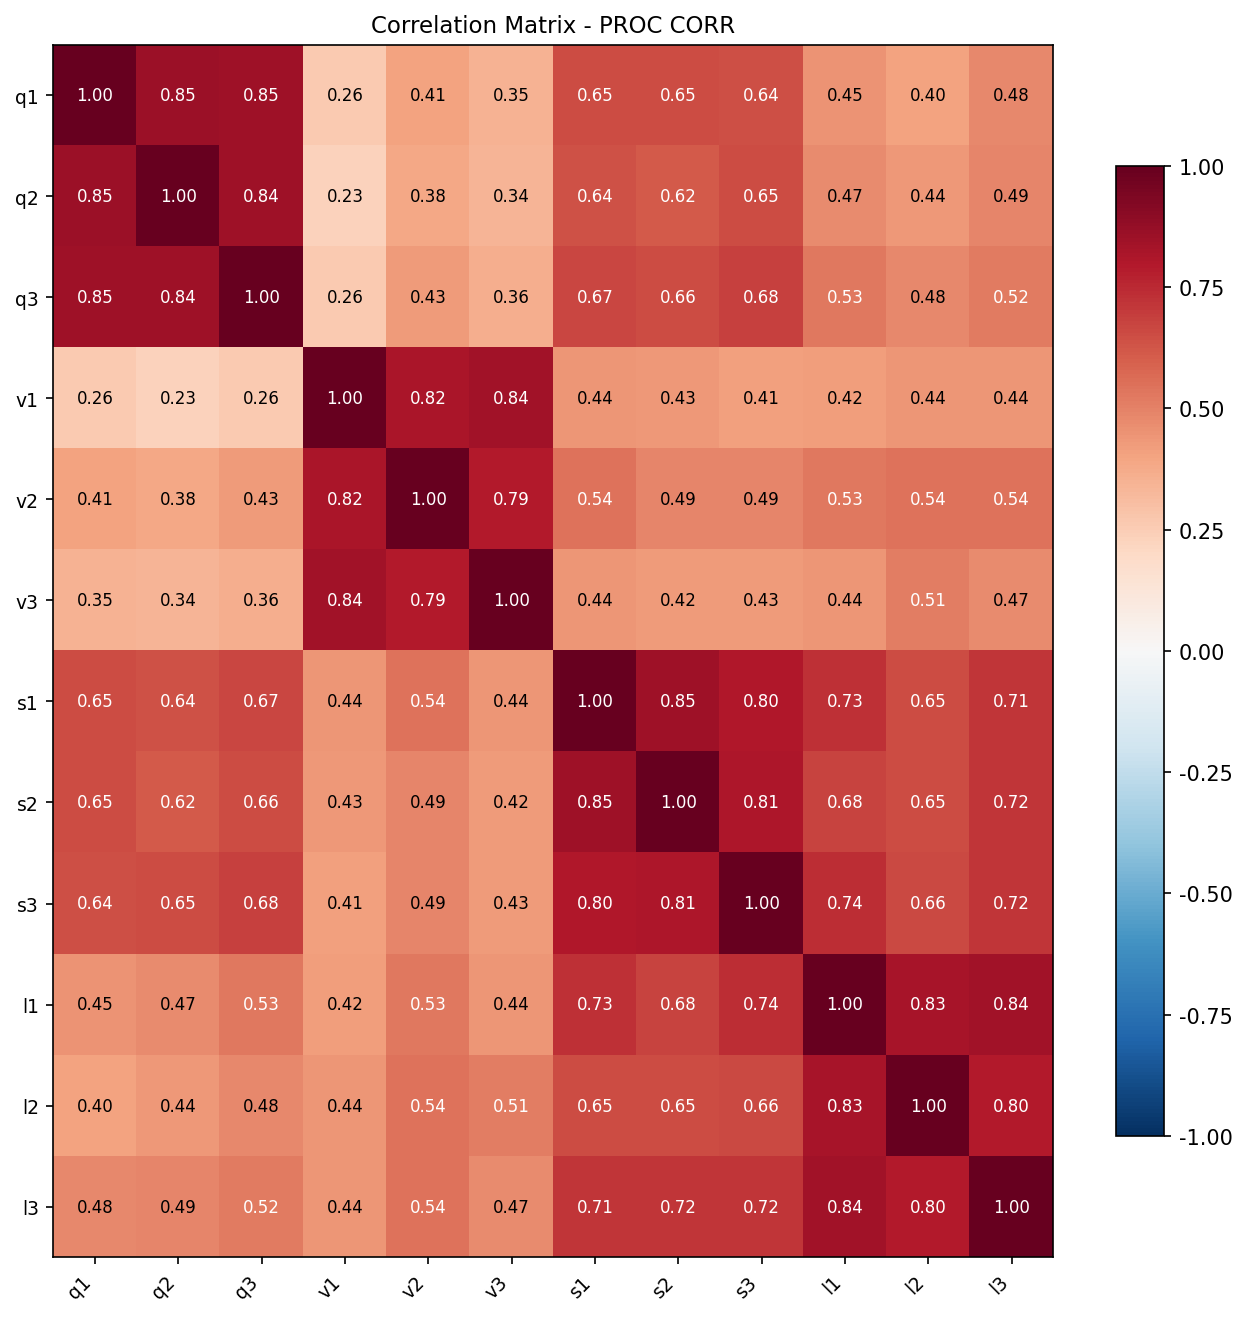

In [2]:
PROCEDURA PRŮMĚRY data=survey n mean std MIN MAX maxdec=2;
   PROMĚNNÁ q1-q3 v1-v3 s1-s3 l1-l3;
   ŠTÍTEK q1="Kvalita služeb – položka 1" q2="Kvalita služeb – položka 2"
          q3="Kvalita služeb – položka 3"
          v1="Hodnota – položka 1" v2="Hodnota – položka 2"
          v3="Hodnota – položka 3"
          s1="Spokojenost – položka 1" s2="Spokojenost – položka 2"
          s3="Spokojenost – položka 3"
          l1="Loajalita – položka 1" l2="Loajalita – položka 2"
          l3="Loajalita – položka 3";
SPUSTIT;

PROCEDURA CORR data=survey nosimple noprob;
   PROMĚNNÁ q1 q2 q3 v1 v2 v3 s1 s2 s3 l1 l2 l3;
SPUSTIT;

## Krok 3 — Sestavení úplného SEM

Specifikace `LINEQS` má dvě vrstvy:

**Měřicí rovnice** — každá pozorovaná položka se rovná faktorové zátěži krát její latentní faktor plus jedinečný chybový člen (`e1`–`e12`). První zátěž každého konstruktu fixujeme na `1.0`, abychom nastavili měřítko latentní proměnné; zbývající zátěže jsou volné parametry (pojmenované `lq2`, `ls3`, ... aby se ve výstupu objevily podle jména). Každý chybový člen je deklarován v příkazu `variance`.

**Strukturní rovnice** — `Satis` je regresována na `ServQual` a `Value`; `Loyal` je regresována na `Satis` a `Value` (malá přímá vazba). Každá endogenní latentní proměnná nese vlastní člen poruchy (`d1` pro spokojenost, `d2` pro loajalitu). Pojmenování strukturních koeficientů (`b_sat_sq`, `b_loy_sat`, ...) usnadňuje jejich odečtení z tabulky odhadů.

Příkaz `variance` deklaruje dvanáct rozptylů chyby měření, dvě strukturní poruchy a dva rozptyly exogenních latentních proměnných; `cov ServQual Value` umožňuje oběma hybatelům korelovat. `method=ml` požaduje odhad metodou maximální věrohodnosti. Výstup uvádí souhrn shody modelu (chí-kvadrát, RMSEA, CFI, TLI) a úplnou tabulku odhadů parametrů se standardními chybami a t-hodnotami.

In [3]:
PROCEDURA calis data=survey METHOD=ml toteff;
   lineqs
      /* --- Měřicí model --- */
      q1 = 1.0 * ServQual + e1,
      q2 = lq2 * ServQual + e2,
      q3 = lq3 * ServQual + e3,
      v1 = 1.0 * VALUE    + e4,
      v2 = lv2 * VALUE    + e5,
      v3 = lv3 * VALUE    + e6,
      s1 = 1.0 * Satis    + e7,
      s2 = ls2 * Satis    + e8,
      s3 = ls3 * Satis    + e9,
      l1 = 1.0 * Loyal    + e10,
      l2 = ll2 * Loyal    + e11,
      l3 = ll3 * Loyal    + e12,
      /* --- Strukturální model --- */
      Satis = b_sat_sq * ServQual + b_sat_val * VALUE + d1,
      Loyal = b_loy_sat * Satis   + b_loy_val * VALUE + d2;
   variance
      e1 e2 e3 e4 e5 e6 e7 e8 e9 e10 e11 e12,
      d1 d2,
      ServQual VALUE;
   COV ServQual VALUE;
SPUSTIT;


                    The CALIS Procedure
              Covariance Structure Analysis

        Sample Covariances

                        respid            q1            q2            q3            v1            v2            v3            s1            s2            s3            l1            l2            l3
respid                841.6667       -3.1963       -5.9002       -5.5689       -2.0259       -1.1817       -1.4188       -3.1339       -1.6622       -2.3867       -1.1765       -2.3018       -1.1323
q1                     -3.1963        1.5413        1.1997        1.1857        0.3560        0.5631        0.3998        0.7908        0.8128        0.7212        0.5751        0.4754        0.5140
q2                     -5.9002        1.1997        1.2869        1.0745        0.2803        0.4884        0.3546        0.7018        0.7055        0.6680        0.5477        0.4689        0.4775
q3                     -5.5689        1.1857        1.0745        1.2597        0.3199    


NOTE: PROC CALIS data=survey

NOTE: Using Python (semopy) for PROC CALIS
NOTE: PROC CALIS completed.


## Krok 4 — Vizualizace strukturních vazeb

Čtyři strukturní koeficienty odhadnuté výše jsou jádrem modelu. Zobrazujeme je vedle sebe grafem, aby byly relativní velikosti — a dominance vazby spokojenost → loajalita — okamžitě viditelné. Vynesené hodnoty jsou odhady metodou maximální věrohodnosti odečtené přímo z tabulky parametrů v Kroku 3.


NOTE: DATA paths

NOTE: Processing inline DATALINES (4 lines)

NOTE: Read 4 rows from DATALINES.
NOTE: Wrote paths (4 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=paths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


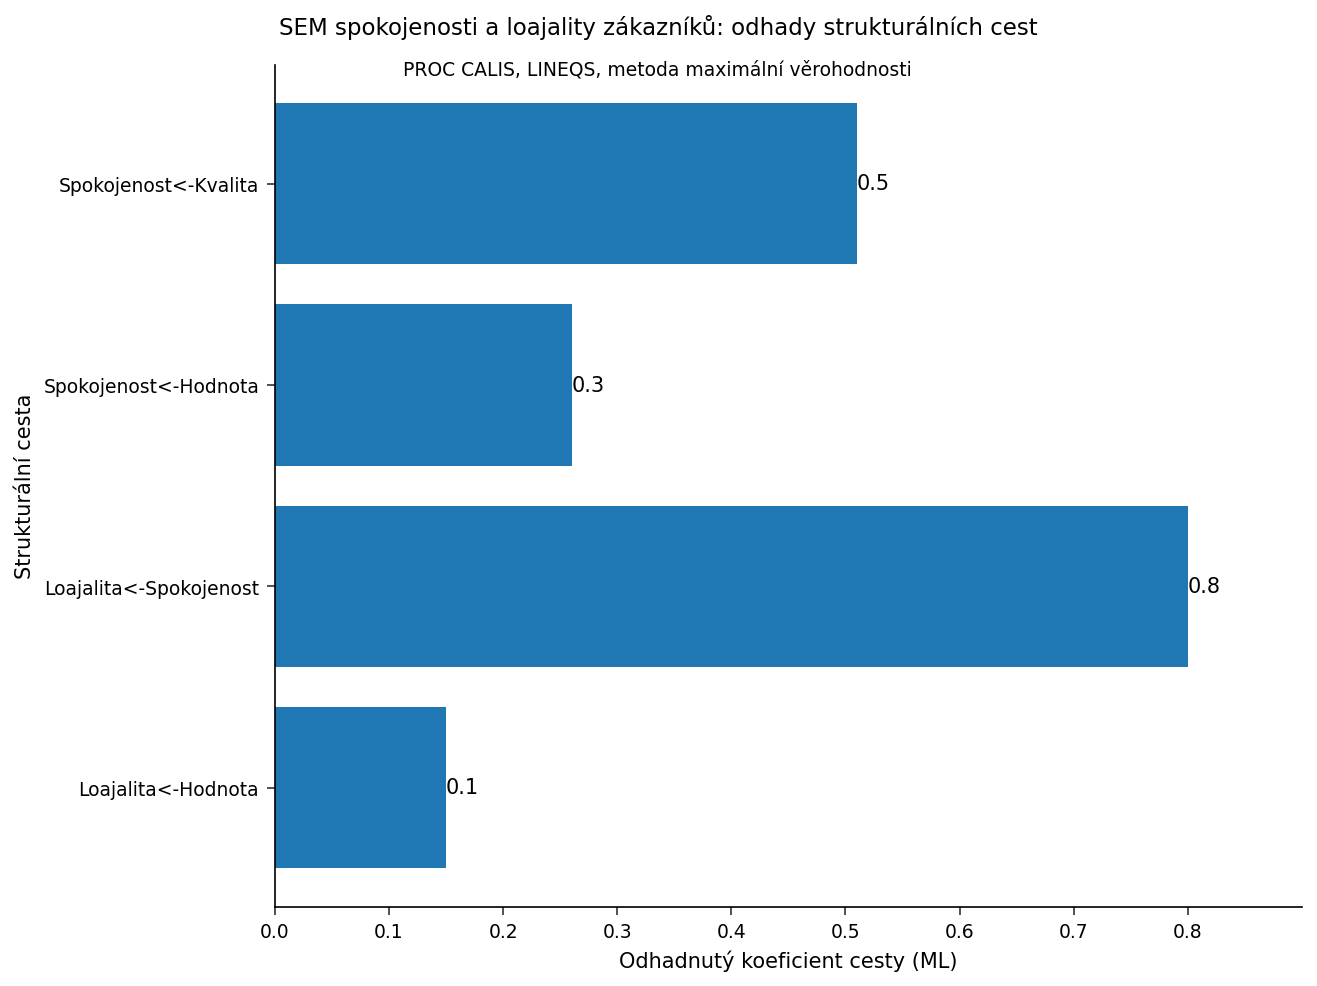

In [4]:
/* Odhady strukturálních cest z výše uvedeného modelu PROC CALIS */
data paths;
   DÉLKA path $40;
   VSTUP path $ coef;
   DATALINES;
Loajalita<-Spokojenost 0.80
Spokojenost<-Kvalita 0.51
Spokojenost<-Hodnota 0.26
Loajalita<-Hodnota 0.15
;
SPUSTIT;

PROCEDURA SGPLOT data=paths;
   HBAR path / RESPONSE=coef DATALABEL
               fillattrs=(color=steelblue);
   XAXIS ŠTÍTEK="Odhadnutý koeficient cesty (ML)" MIN=0 MAX=0.9;
   YAXIS ŠTÍTEK="Strukturální cesta" discreteorder=data;
   NÁZEV  "SEM spokojenosti a loajality zákazníků: odhady strukturálních cest";
   title2 "PROC CALIS, LINEQS, metoda maximální věrohodnosti";
SPUSTIT;

## Interpretace výsledků

**Měřicí model.** Každá uvolněná zátěž je velká a vysoce významná (všechny t > 13, p < 0,0001): `q2`/`q3` sytí ~0,91 na ServQual, `v2`/`v3` sytí ~0,99 a 0,84 na Value, `s2`/`s3` sytí ~1,03 a 0,90 na Satis a `l2`/`l3` sytí ~0,88 a 0,82 na Loyal. Rozptyly chyby jsou skromné vzhledem k rozptylům indikátorů, takže každá třípoložková baterie čistě měří svůj zamýšlený konstrukt — kontrola validity, která ospravedlňuje zacházení s položkami jako se zástupci latentních konstruktů.

**Strukturní model.** Odhadnuté vazby odpovídají na obchodní otázku přímo:
- **Spokojenost** je poháněna více **kvalitou služeb** (`b_sat_sq` = 0,51, t = 7,99) než **vnímanou hodnotou** (`b_sat_val` = 0,26, t = 3,86). Investice do kvality služeb posouvá spokojenost zhruba dvakrát více na jednotku.
- **Loajalita** je ovládána **spokojeností** (`b_loy_sat` = 0,80, t = 8,54) s pouze malou *přímou* vazbou hodnoty (`b_loy_val` = 0,15, t = 2,02), která obchází spokojenost.
- Oba hybatelé jsou kladně korelovaní (kovariance ServQual–Value 0,44, t = 3,36), jak se očekává, když oba odrážejí sdílenou skrytou zkušenost.

**Rozklad účinku.** Vynásobení podél řetězce odděluje nepřímý (skrze spokojenost) kanál od přímého:
- **Hodnota → loajalita:** nepřímý = 0,26 × 0,80 = **0,21**, přímý = **0,15**, celkem ≈ **0,36**. Většina tahu hodnoty na loajalitu proudí skrze spokojenost.
- **Kvalita služeb → loajalita:** neexistuje přímá vazba, takže celý účinek je nepřímý = 0,51 × 0,80 = **0,41** — jediný největší hybatel loajality v modelu.

To kvantifikuje strategické tvrzení: *zlepšení spokojenosti je primární pákou pro loajalitu* a kvalita služeb je nejúčinnějším způsobem, jak vůbec spokojenost zvýšit.

**Shoda modelu.** Model dobře reprodukuje pozorované kovariance — chí-kvadrát = 50,81 (df = 49, p = 0,40, nevýznamná hodnota indikující žádnou zjistitelnou neshodu), RMSEA = 0,019 (výrazně pod prahem „těsné shody“ 0,05), CFI = 0,999 a TLI = 0,998 (obě nad referenční hodnotou 0,95). Předpokládaný řetězec, v němž spokojenost zprostředkovává loajalitu, je plně konzistentní s daty.

Stručně řečeno: maloobchodník může odečíst, kolik loajality je *vytvořeno skrze spokojenost* a který hybatel — kvalita služeb nebo hodnota — nejúčinněji zvyšuje spokojenost v prvé řadě.